In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

In [2]:
X, y = make_classification(n_samples = 100, n_features = 2, n_informative = 1, n_redundant = 0,
                          n_classes = 2, n_clusters_per_class = 1, random_state = 41,
                          hypercube = False, class_sep = 10)

In [6]:
X.shape

(100, 2)

In [7]:
X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [11]:
X.shape

(100, 2)

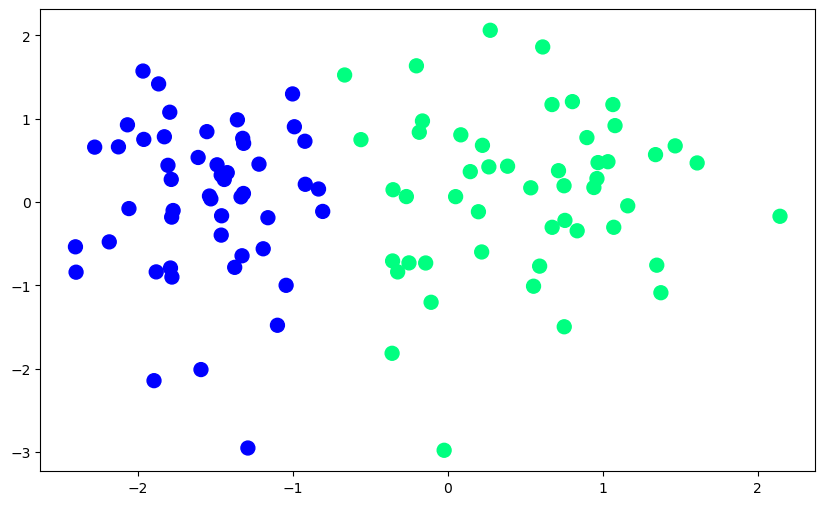

In [3]:
plt.figure(figsize = (10,6))
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'winter', s = 100)

In [8]:
np.insert(X, 0, 1, axis = 1)

array([[ 1.        ,  0.19924745, -0.11697552],
       [ 1.        , -0.24882029, -0.73115232],
       [ 1.        , -0.3544904 , -0.7081059 ],
       [ 1.        , -1.59086506, -2.01199214],
       [ 1.        , -0.20083951,  1.63493163],
       [ 1.        , -0.83241122,  0.15599044],
       [ 1.        , -1.79207014,  1.07782053],
       [ 1.        ,  0.0856607 ,  0.80626713],
       [ 1.        , -0.55865299,  0.74859527],
       [ 1.        , -1.95974262,  0.75152794],
       [ 1.        , -1.77828947, -0.90114581],
       [ 1.        , -1.77985853, -0.1815243 ],
       [ 1.        , -0.02194151, -2.98092432],
       [ 1.        ,  0.80563431,  1.20500136],
       [ 1.        , -1.82701214,  0.78302407],
       [ 1.        ,  0.38730728,  0.42968688],
       [ 1.        , -0.14108668, -0.73229726],
       [ 1.        , -1.87955941, -0.83930476],
       [ 1.        , -0.18232911,  0.83727062],
       [ 1.        , -1.77059533, -0.10255323],
       [ 1.        , -2.27658028,  0.658

In [9]:
np.ones(X.shape[1])

array([1., 1.])

In [19]:
def perceptron(X, y):
    X = np.insert(X, 0, 1, axis = 1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0, 100)
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]

    return weights[0], weights[1:]

In [20]:
def step(z):
    return 1 if z > 0 else 0

In [21]:
intercept_, coef_ = perceptron(X, y)

In [22]:
print(coef_)
print(intercept_)

[1.32088936 0.21502796]
1.0


In [24]:
m = -(coef_[0] / coef_[1])
c = -(intercept_ / coef_[1])

In [25]:
X_input = np.linspace(-3, 3, 100)
y_input = m * X_input + c

(-3.0, 2.0)

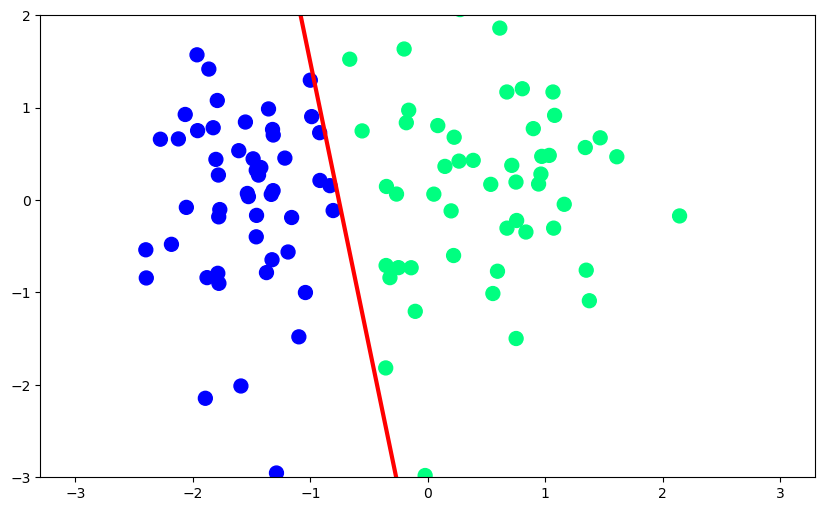

In [26]:
plt.figure(figsize = (10,6))
plt.plot(X_input, y_input, color = 'red', linewidth = 3)
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'winter', s = 100)
plt.ylim(-3, 2)

## Using sklearn

In [29]:
lor = LogisticRegression()
lor.fit(X, y)

LogisticRegression()

In [35]:
print(lor.coef_)
print(lor.intercept_)

[[3.50144121 0.02773483]]
[2.25106636]


In [34]:
m = -(lor.coef_[0][0] / lor.coef_[0][1])
c = -(intercept_ / lor.coef_[0][1])

In [36]:
X_input1 = np.linspace(-3, 3, 100)
y_input1 = m * X_input + c

(-3.0, 2.0)

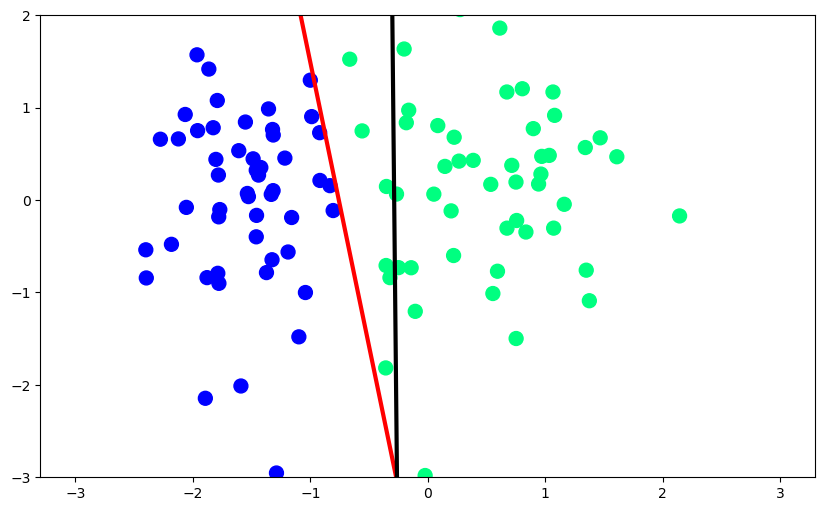

In [41]:
plt.figure(figsize=(10,6))
plt.plot(X_input, y_input, color = 'red', linewidth = 3)
plt.plot(X_input1, y_input1, color = 'black', linewidth = 3)
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'winter', s = 100)
plt.ylim(-3, 2)